In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

In [3]:
with open("../data/names.txt", 'r') as f:
    words = f.read().splitlines()

In [4]:
start = ord('a'); end = start + 26
chs = [chr(i) for i in range(start, end)]

stoi = {s:i+1 for i, s in enumerate(chs)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}

In [5]:

def build_dataset(words):

    X, y = [], []

    blocksize = 3
    for w in words:
        context = [0] * blocksize

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)
            # print(''.join(itos[i] for i in context) + '--->' + itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    y = torch.tensor(y)

    return X, y

random.seed(101)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, y_train = build_dataset(words[:n1])
X_dev, y_dev = build_dataset(words[n1:n2])
X_test, y_test = build_dataset(words[n2:])


In [ ]:
g = torch.Generator().manual_seed(2147483647)

emb_size = 2
block_size = 3
hidden_size = 100
vocb_size = 27

C = torch.randn((vocb_size, emb_size))

W1 = torch.randn((emb_size * block_size, hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, vocb_size), generator=g)
b2 = torch.randn(vocb_size, generator=g)

parameters = [C, W1, b1, W2, b2]


In [7]:
sum(p.nelement() for p in parameters)

3481

In [8]:
for p in parameters:
    p.requires_grad = True

## Finding a descent learning rate

In [9]:
# choosing the learning rate between 0.001 and 1
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [10]:
lrei = []
losses = []

In [11]:
for i in range(1000):
    # construct mini batches
    ix = torch.randint(0, X_train.shape[0], (32,))

    # forward pass
    emb = C[X_train[ix]] # (inputs, 3, 2)
    Z1 = emb.view((-1, 6)) @ W1 + b1 # (inputs, outputs1 : 100)
    A1 = Z1.tanh() # (inputs, outputs 1 : 100)
    Z2 = A1 @ W2 + b2 # (inputs, outputs2 : 27)
    loss = F.cross_entropy(Z2, y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data -= lrs[i] * p.grad

    lrei.append(lre[i])
    losses.append(loss.item())
    # print(loss.item())

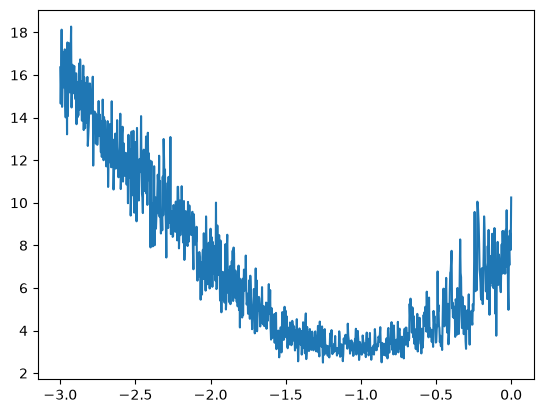

In [12]:
plt.plot(lrei, losses)

In [13]:
for i in range(50000):
    # construct mini batches
    ix = torch.randint(0, X_train.shape[0], (32,))

    # forward pass
    emb = C[X_train[ix]] # (inputs, 3, 2)
    Z1 = emb.view((-1, 6)) @ W1 + b1 # (inputs, outputs1 : 100)
    A1 = Z1.tanh() # (inputs, outputs 1 : 100)
    Z2 = A1 @ W2 + b2 # (inputs, outputs2 : 27)
    loss = F.cross_entropy(Z2, y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data -= 0.01 * p.grad

    

In [14]:
emb = C[X_train]
Z1 = emb.view(-1, 6) @ W1 + b1
A1 = Z1.tanh()
Z2 = A1 @ W2 + b2

loss = F.cross_entropy(Z2, y_train)
loss.item()

2.387911081314087

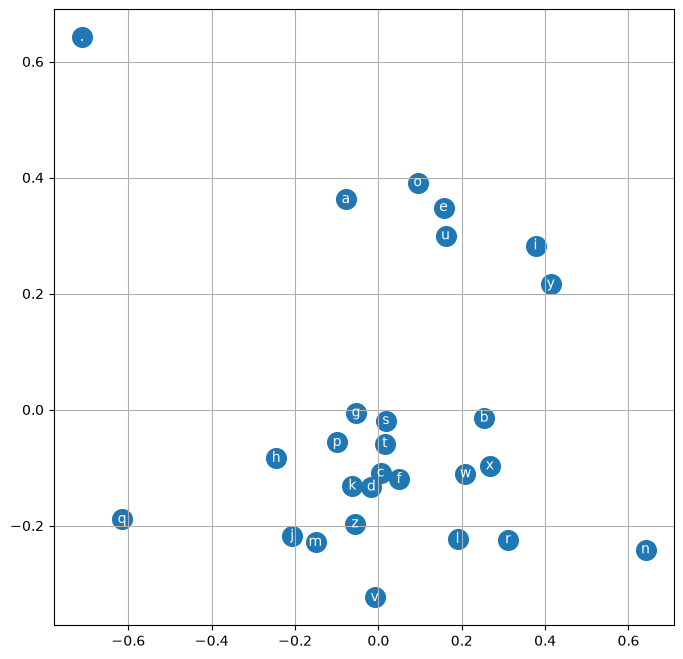

In [15]:
plt. figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:, 1].data, s=200)
for i in range(C. shape [0]):
    plt. text(C[i,0].item(), C[i,1]. item(), itos[i], ha="center", va="center", color='white')
plt.grid()

In [16]:
emb = C[X_dev]
Z1 = emb.view(-1, 6) @ W1 + b1
A1 = Z1.tanh()
Z2 = A1 @ W2 + b2

loss = F.cross_entropy(Z2, y_dev)
loss.item()

2.3845038414001465

## Sampling from our model

In [17]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    context = [0] * 3
    word = ""

    while True:
        emb = C[torch.tensor([context])] # (1, block_size, emb_size)
        Z1 = emb.view(1, -1) @ W1 + b1
        A1 = Z1.tanh()
        Z2 = A1 @ W2 + b2

        probs = F.softmax(Z2, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        char = itos[ix]
        word += char

        context = context[1:] + [ix]
        if ix == 0:
            break
    
    print(word)
    

dex.
marogliuraile.
kayda.
koliminna.
nrlenan.
kan.
a.
samiyah.
jarsrigotas.
moliellavo.
kerteda.
kaleyda.
sadly.
akaviyn.
ratls.
mhinin.
bvtahlas.
kasdr.
ban.
jlen.
